In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

In [2]:
def generate_ar_process(lags, coefs, length):
    
    #cast coefs to np array
    coefs = np.array(coefs)
    
    #initial values
    series = [np.random.normal() for _ in range(lags)]
    
    for _ in range(length):
        #get previous values of the series, reversed
        prev_vals = series[-lags:][::-1]
        
        #get new value of time series
        new_val = np.sum(np.array(prev_vals) * coefs) + np.random.normal()
        
        series.append(new_val)
        
    return np.array(series)

In [3]:
def perform_adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])

# AR(1) Process

## Stationary

In [4]:
ar_1_process = generate_ar_process(1, [0.5], 100)
ar_1_process

array([ 1.57586662e+00,  1.06104628e+00, -1.01391895e+00,  4.75558685e-01,
        1.34275507e+00, -7.81655195e-01,  8.25492846e-01,  1.99552040e-01,
       -4.42862732e-01, -4.53086378e-01, -7.73353474e-02, -1.73488485e+00,
       -7.79560146e-01,  1.42276551e+00,  1.29328334e+00,  2.42124241e+00,
        1.92742584e+00,  1.40514555e+00,  7.01525153e-01,  1.86996642e+00,
        2.29665929e+00,  1.30737466e+00,  5.61411421e-01, -2.02247308e+00,
       -8.85398421e-02, -6.88940812e-01, -9.26562500e-01, -1.17729141e+00,
       -1.49834595e+00,  3.20358179e-01, -1.80139387e+00, -1.83551522e+00,
       -2.47651863e+00,  1.67451232e-01,  1.16034803e+00, -3.87258354e-01,
        2.61249458e-01,  2.69413347e+00,  1.63065882e+00, -6.92039690e-01,
        7.74114453e-01,  2.29164087e+00,  2.94287501e+00,  2.05002112e-01,
        1.57300672e-02,  7.53502278e-01,  7.37357371e-01,  6.98703521e-02,
        5.09313016e-01,  9.50873523e-01, -4.07102794e-01,  4.51217827e-01,
       -6.93708461e-01, -

In [5]:
df_ar_1_process = pd.DataFrame(data=ar_1_process, columns=['value'])
df_ar_1_process['delta'] = df_ar_1_process['value'].diff()
df_ar_1_process['t-1'] = df_ar_1_process['value'].shift(1)
df_ar_1_process

,value,delta,t-1
0,1.575867,NaN,NaN
1,1.061046,-0.514820,1.575867
2,-1.013919,-2.074965,1.061046
3,0.475559,1.489478,-1.013919
4,1.342755,0.867196,0.475559
...,...,...,...
96,-1.642168,-0.325093,-1.317075
97,-0.781901,0.860267,-1.642168
98,-0.280445,0.501456,-0.781901
99,-0.267082,0.013363,-0.280445


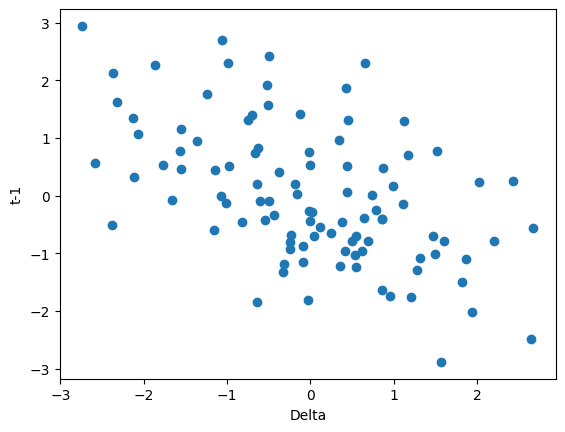

In [6]:
plt.scatter(df_ar_1_process['delta'], df_ar_1_process['t-1'])
plt.xlabel('Delta')  # Name for x-axis
plt.ylabel('t-1')    # Name for y-axis
plt.show()

Text(0.5, 1.0, 'Stationary AR(1) Process')

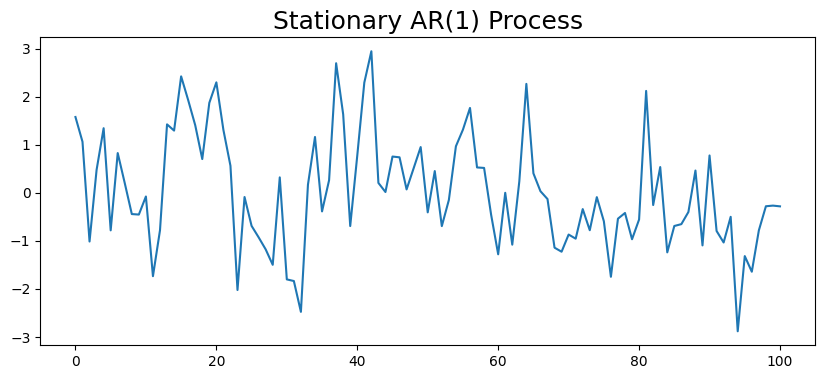

In [7]:
plt.figure(figsize=(10,4))
plt.plot(ar_1_process)
plt.title('Stationary AR(1) Process', fontsize=18)

In [8]:
perform_adf_test(ar_1_process)

ADF Statistic: -6.068555
p-value: 0.000000


## Non-Stationary

In [9]:
ar_1_process_unit_root = generate_ar_process(1, [1], 100)
ar_1_process_unit_root

array([ 0.18147034, -0.5982952 , -2.42740164, -2.94939826, -4.54670222,
       -4.4183937 , -2.7642645 , -3.28486424, -3.55578168, -2.03211028,
       -2.25904145,  0.31115074,  0.09693533, -0.48228171,  0.55580507,
        0.54763782,  0.32862825,  1.5514286 ,  2.9872707 ,  4.11309666,
        3.41547637,  2.96134858,  3.03876393,  3.79114048,  3.16427484,
        4.17404905,  4.50049991,  4.06831799,  3.80905736,  4.24293547,
        3.3413716 ,  3.13459227,  2.22673188,  2.67206294,  3.00977807,
        2.57232872,  2.73202655,  1.2008635 ,  2.36902006,  1.66386777,
        1.85850093,  1.76805285,  0.97570935, -0.70399271, -1.61458842,
       -2.41817315, -3.9592774 , -4.93850545, -5.32065497, -6.93314276,
       -7.10763874, -5.7731236 , -5.65942561, -7.22387931, -7.69399243,
       -7.25620657, -8.39682949, -5.54064273, -7.09108736, -7.27673161,
       -6.73441174, -6.51550919, -5.44533773, -4.91748952, -4.27532807,
       -3.837364  , -4.41244596, -4.12720957, -3.99488338, -5.10

In [10]:
df_ar_1_process_unit_root = pd.DataFrame(data=ar_1_process_unit_root, columns=['value'])
df_ar_1_process_unit_root['delta'] = df_ar_1_process_unit_root['value'].diff()
df_ar_1_process_unit_root['t-1'] = df_ar_1_process_unit_root['value'].shift(1)
df_ar_1_process_unit_root

,value,delta,t-1
0,0.181470,NaN,NaN
1,-0.598295,-0.779766,0.181470
2,-2.427402,-1.829106,-0.598295
3,-2.949398,-0.521997,-2.427402
4,-4.546702,-1.597304,-2.949398
...,...,...,...
96,-6.311631,-0.186476,-6.125155
97,-5.583528,0.728103,-6.311631
98,-6.274732,-0.691204,-5.583528
99,-6.338186,-0.063454,-6.274732


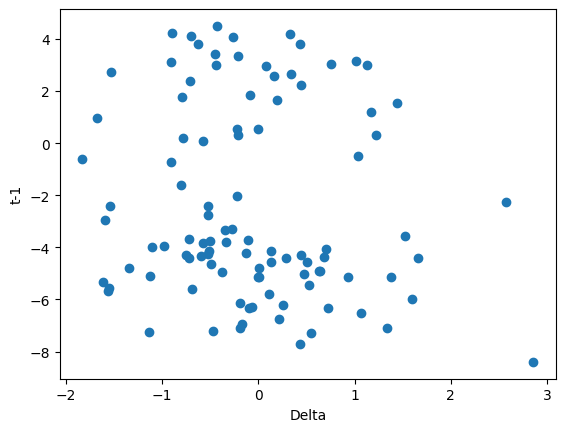

In [11]:
plt.scatter(df_ar_1_process_unit_root['delta'], df_ar_1_process_unit_root['t-1'])
plt.xlabel('Delta')  # Name for x-axis
plt.ylabel('t-1')    # Name for y-axis
plt.show()

Text(0.5, 1.0, 'Non-Stationary AR(1) Process')

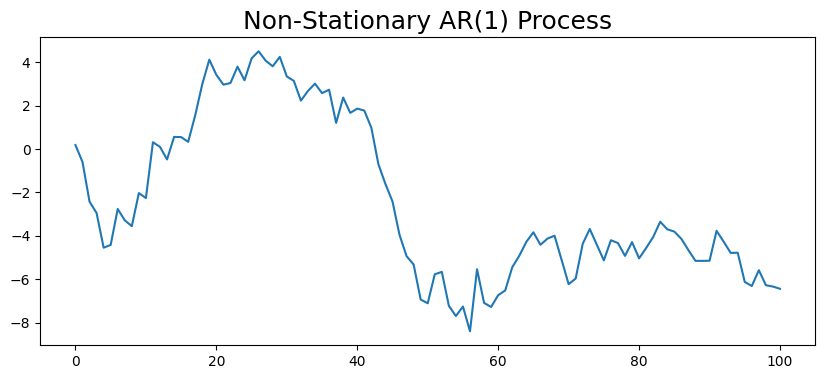

In [12]:
plt.figure(figsize=(10,4))
plt.plot(ar_1_process_unit_root)
plt.title('Non-Stationary AR(1) Process', fontsize=18)

In [13]:
perform_adf_test(ar_1_process_unit_root)

ADF Statistic: -1.083339
p-value: 0.721670


# AR(2) Process

## Stationary

Text(0.5, 1.0, 'Stationary AR(2) Process')

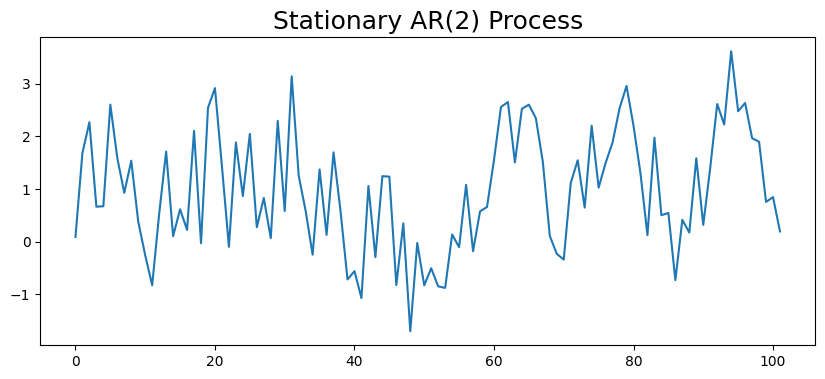

In [14]:
ar_2_process = generate_ar_process(2, [.5, .3], 100)
plt.figure(figsize=(10,4))
plt.plot(ar_2_process)
plt.title('Stationary AR(2) Process', fontsize=18)

In [15]:
perform_adf_test(ar_2_process)

ADF Statistic: -3.891374
p-value: 0.002099


## Non-Stationary

Text(0.5, 1.0, 'Non-Stationary AR(2) Process')

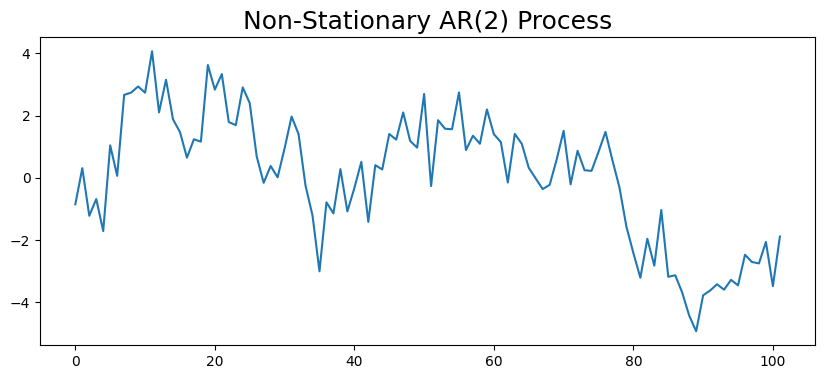

In [16]:
ar_2_process_unit_root = generate_ar_process(2, [.7, .3], 100)
plt.figure(figsize=(10,4))
plt.plot(ar_2_process_unit_root)
plt.title('Non-Stationary AR(2) Process', fontsize=18)

In [17]:
perform_adf_test(ar_2_process_unit_root)

ADF Statistic: -1.362548
p-value: 0.600094
